# Configuration

In [1]:
import os
import json
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')

DATASET = "elife"
SPLIT = "train"

# Functions

In [2]:
def read_evals(
    dataset: str, split: str, method: str = "extractive", directory: str = "."
) -> pd.DataFrame:
    prefix = f"{method}_{dataset}_{split}_"
    files = [
        filename
        for filename in os.listdir(directory)
        if filename.startswith(prefix) and filename.endswith(".json")
    ]

    evals = []
    for filename in files:
        base = filename.replace(prefix, "").replace(".json", "")
        model, count_str = base.rsplit("_", 1)
        count = int(count_str)

        path = os.path.join(directory, filename)
        with open(path, "r") as f:
            metrics = json.load(f)

        row = {"file": filename, "model": model, "count": count}
        row.update(metrics)
        evals.append(row)

    return pd.DataFrame(evals)


def normalize_by_metric(df: pd.DataFrame, exclude: list = None) -> pd.DataFrame:
    if exclude is None:
        exclude = ["file", "model", "count"]

    metric_cols = [c for c in df.columns if c not in exclude]
    df_norm = df.copy()

    for col in metric_cols:
        min_val, max_val = df[col].min(), df[col].max()
        if max_val > min_val:
            df_norm[col] = (df[col] - min_val) / (max_val - min_val)
        else:
            df_norm[col] = 0.5

    df_norm["score"] = df_norm[metric_cols].mean(axis=1)

    return df_norm


def plot_evals(df: pd.DataFrame):
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=df.sort_values("count"),
        x="count",
        y="score",
        hue="model",
        marker="o",
    )
    plt.title("Score by Model and Sentence Count")
    plt.xlabel("Number of Sentences")
    plt.ylabel("Score (min-max average)")
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()


def pairwise_comparison(
    method1: dict,
    method2: dict,
    method_names=("Method 1", "Method 2"),
) -> str:
    name1, name2 = method_names
    lower_is_better = {"FKGL", "DCRS", "CLI"}

    wins1 = wins2 = 0
    common_metrics = sorted(method1.keys() & method2.keys())
    for m in common_metrics:
        v1, v2 = method1[m], method2[m]
        comparison = v1 < v2 if m in lower_is_better else v1 > v2
        wins1 += comparison
        wins2 += (v2 != v1) and not comparison

    if wins1 > wins2:
        print(f"{name1} is better on {wins1}/{len(common_metrics)} metrics.\n\n")
    elif wins2 > wins1:
        print(f"{name2} is better on {wins2}/{len(common_metrics)} metrics.\n\n")
    else:
        print("Tie")

    df = pd.DataFrame(
        [{"metric": m, "method": name1, "value": method1[m]} for m in common_metrics]
        + [{"metric": m, "method": name2, "value": method2[m]} for m in common_metrics]
    )

    n = len(common_metrics)
    ncols = min(3, n)
    nrows = math.ceil(n / ncols)
    figure, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten() if n > 1 else [axes]

    for i, m in enumerate(common_metrics):
        ax = axes[i]
        sub = df[df["metric"] == m]
        sns.barplot(data=sub, x="method", y="value", hue="method", ax=ax)
        ax.set_title(m)
        ax.set_ylabel("Value")
        ax.set_xlabel("")

    for ax in axes[n:]:
        figure.delaxes(ax)

    plt.tight_layout()
    plt.show()

# Analysis

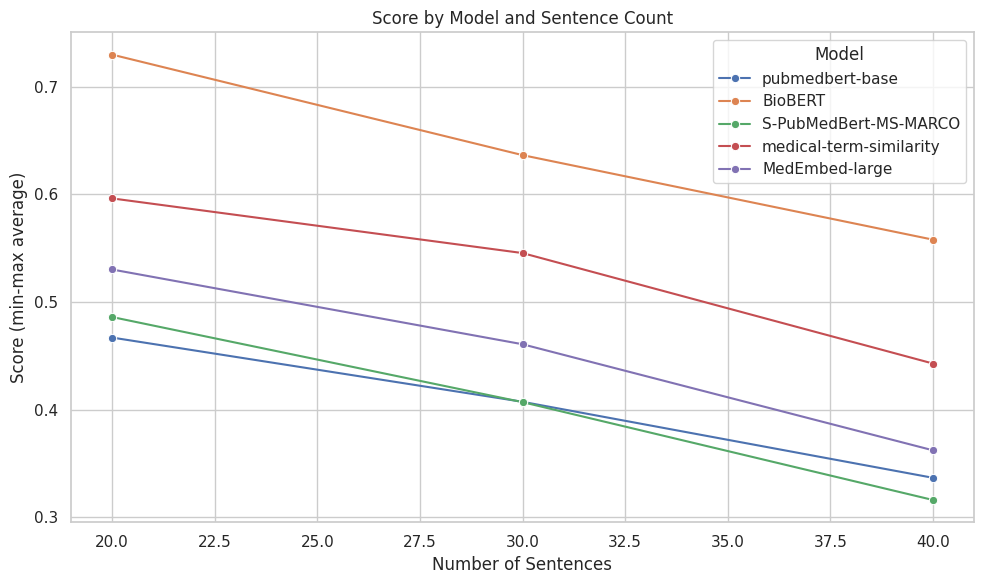

In [ ]:
plot_evals(normalize_by_metric(read_evals(DATASET, SPLIT)))

# eLife

In [54]:
biobert10_eval = json.loads("""
{
  "ROUGE": 0.2846802771532597,
  "BLEU": 4.095003577724864,
  "METEOR": 0.22584480990166966,
  "BERTScore": 0.8352167475223541,
  "FKGL": 17.369999999999997,
  "DCRS": 10.725500000000002,
  "CLI": 16.5059,
  "AlignScore": 0.9554532057046891,
  "LENS": 19.45389507928554,
  "SummaC": 0.9000735971331596
}
""")
biobert20_eval = json.loads("""
{
  "ROUGE": 0.2843115239775706,
  "BLEU": 3.552657661082773,
  "METEOR": 0.29566891785091143,
  "BERTScore": 0.8318108862638474,
  "FKGL": 16.594,
  "DCRS": 9.926799999999998,
  "CLI": 15.891300000000003,
  "LENS": 11.325958328083216,
  "AlignScore": 0.9020975017547608,
  "SummaC": 0.8602359047532082
}
""")
llama_eval = json.loads("""
{
  "ROUGE": 0.3400603454482949,
  "BLEU": 5.850971829149868,
  "METEOR": 0.26388238068860126,
  "BERTScore": 0.8395288509130477,
  "FKGL": 12.815000000000003,
  "DCRS": 8.368500000000001,
  "CLI": 13.564400000000001,
  "AlignScore": 0.5887154772877693,
  "LENS": 65.84658642650844,
  "SummaC": 0.494549036026001
}
""")
extractive_zeroshot30_eval = json.loads("""
{
  "ROUGE": 0.34218369698829526,
  "BLEU": 5.529833812344565,
  "METEOR": 0.26088997398733066,
  "BERTScore": 0.83397283742042,
  "FKGL": 10.868049792531119,
  "DCRS": 8.040290456431535,
  "CLI": 11.938174273858923,
  "AlignScore": 0.5254511907387571,
  "LENS": 66.19848049561101,
  "SummaC": 0.5116029901128587
}
""")
finetuned_biobert10_e1_eval = json.loads("""
{
  "ROUGE": 0.3614581387146478,
  "BLEU": 7.594740976418369,
  "METEOR": 0.2814994768387161,
  "BERTScore": 0.850679917701547,
  "FKGL": 9.290041493775933,
  "DCRS": 7.234647302904565,
  "CLI": 10.036224066390039,
  "AlignScore": 0.6442585630782907,
  "LENS": 73.51792045150412,
  "SummaC": 0.6176202105536006
}
""")
finetuned_biobert20_e1_eval = json.loads("""
{
  "ROUGE": 0.3720397456834828,
  "BLEU": 8.20158646330169,
  "METEOR": 0.2849767971803836,
  "BERTScore": 0.8534785462118283,
  "FKGL": 9.140663900414937,
  "DCRS": 7.295767634854773,
  "CLI": 9.893360995850623,
  "AlignScore": 0.6584241977618444,
  "LENS": 75.93397619988295,
  "SummaC": 0.6245190563043618
}
""")
finetuned_biobert20_e2_eval = json.loads("""
{
  "ROUGE": 0.36603984519691934,
  "BLEU": 7.252777199191996,
  "METEOR": 0.27232936446327605,
  "BERTScore": 0.8536375563174362,
  "FKGL": 9.33402489626556,
  "DCRS": 7.528630705394192,
  "CLI": 10.074481327800829,
  "AlignScore": 0.6150173246860504,
  "LENS": 77.78214820485148,
  "SummaC": 0.6220851264801263
}
""")
finetuned_biobert30_e1_eval = json.loads("""
{
  "ROUGE": 0.3737825809797754,
  "BLEU": 8.140139027104818,
  "METEOR": 0.28434496148547744,
  "BERTScore": 0.8542264546596163,
  "FKGL": 9.240248962655604,
  "DCRS": 7.340082987551868,
  "CLI": 10.027759336099585,
  "AlignScore": 0.6523464827864002,
  "LENS": 75.58734747748147,
  "SummaC": 0.6186429996708122
}
""")
finetuned_biobert40_e1_eval = json.loads("""
{
  "ROUGE": 0.37972329003998423,
  "BLEU": 8.526024686078946,
  "METEOR": 0.289781549975091,
  "BERTScore": 0.8554381040616649,
  "FKGL": 9.369294605809129,
  "DCRS": 7.405850622406639,
  "CLI": 10.230331950207468,
  "AlignScore": 0.661226114049492,
  "LENS": 75.13989734698133,
  "SummaC": 0.6299863493541464
}
""")
finetuned_biobert40_e2_eval = json.loads("""
{
  "ROUGE": 0.3792364992977853,
  "BLEU": 8.420492478927397,
  "METEOR": 0.2852381034464312,
  "BERTScore": 0.8567511043607942,
  "FKGL": 9.003734439834023,
  "DCRS": 7.533983402489627,
  "CLI": 10.008091286307055,
  "AlignScore": 0.6433443417192989,
  "LENS": 78.47242125545766,
  "SummaC": 0.6452550525734534
}
""")

## Extractive Models

### BioBERT(20) vs. BioBERT(10)

BioBERT(10) is better on 6/10 metrics.




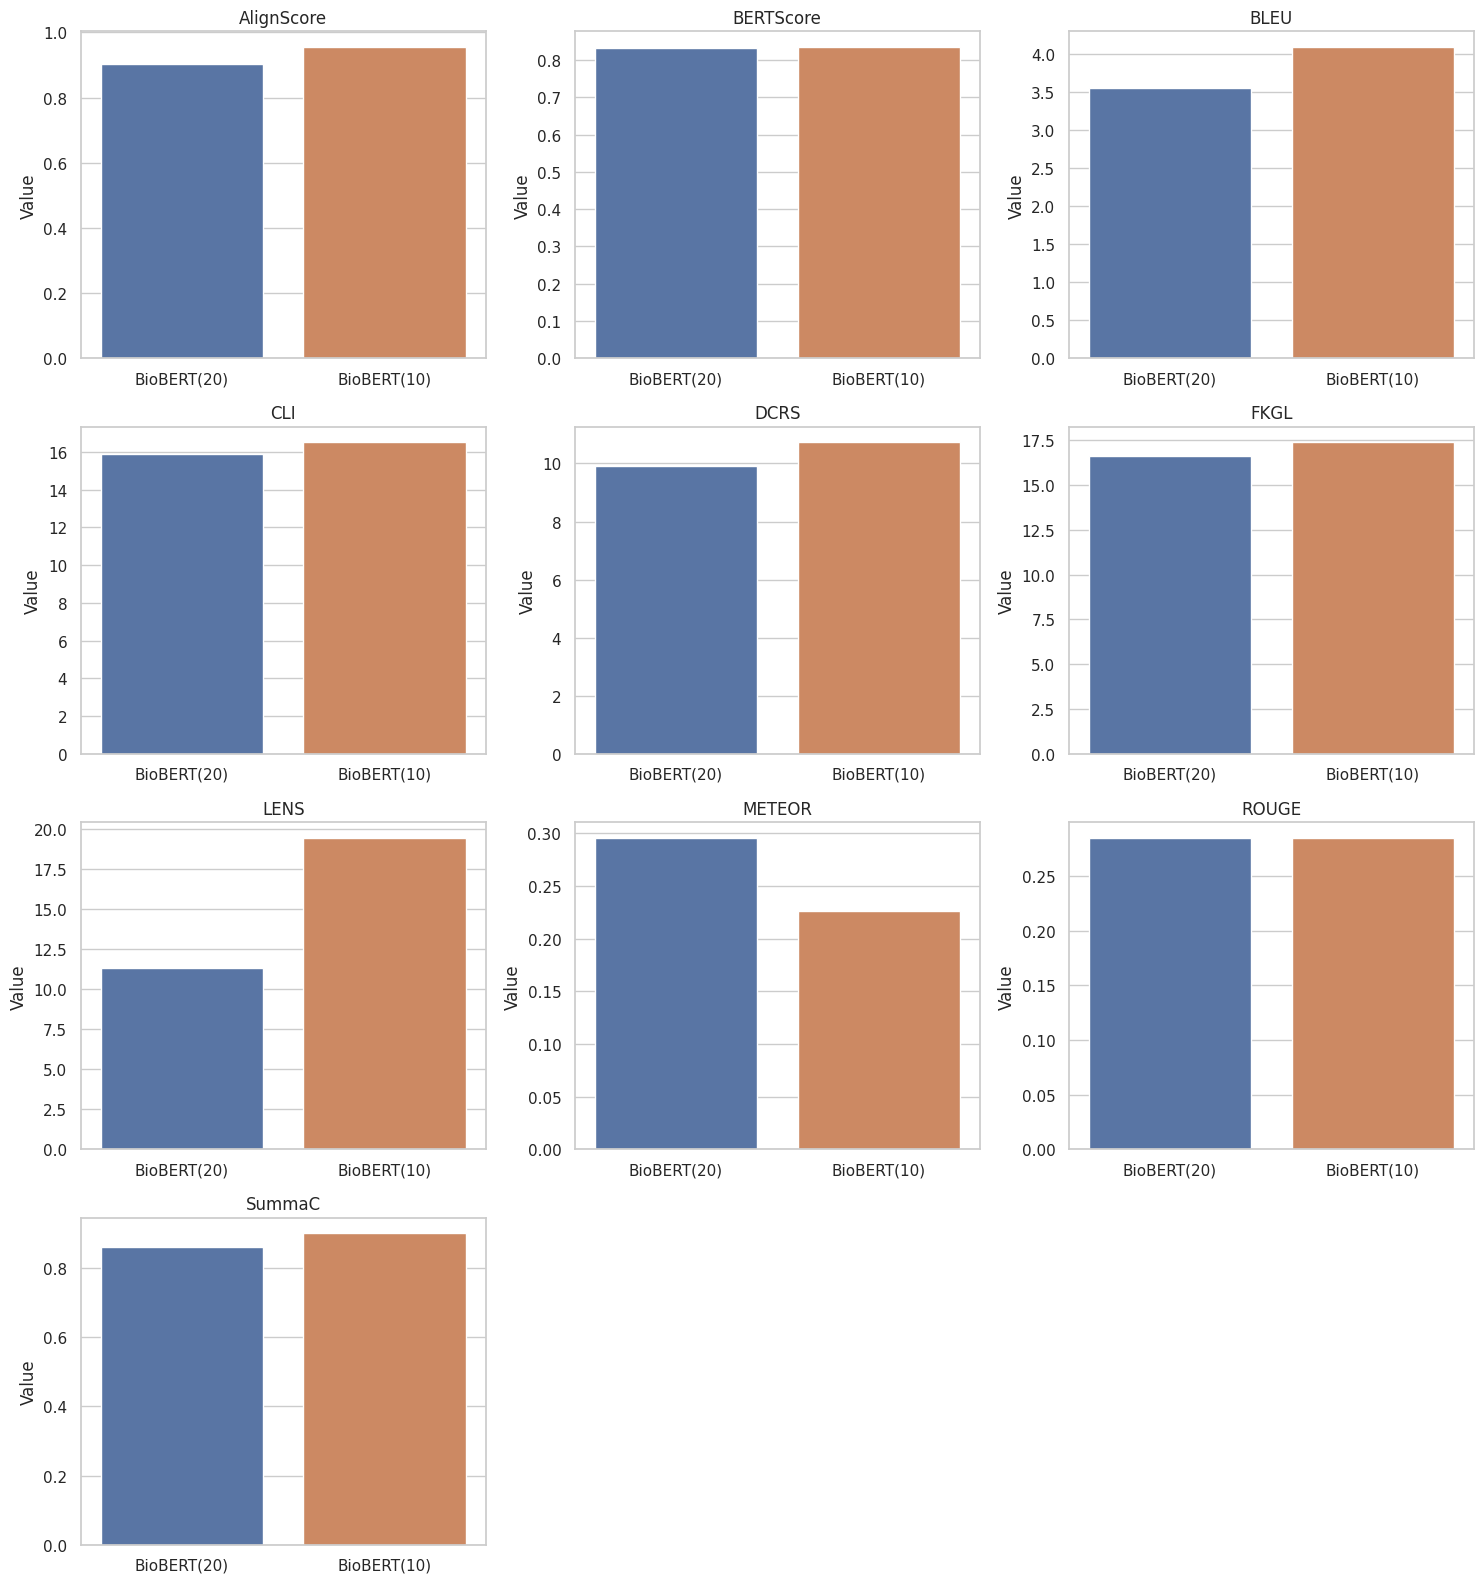

In [55]:
pairwise_comparison(biobert20_eval, biobert10_eval, ("BioBERT(20)", "BioBERT(10)"))

### Llama Zero-Shot vs. BioBERT(10)

Llama Zero-Shot is better on 8/10 metrics.




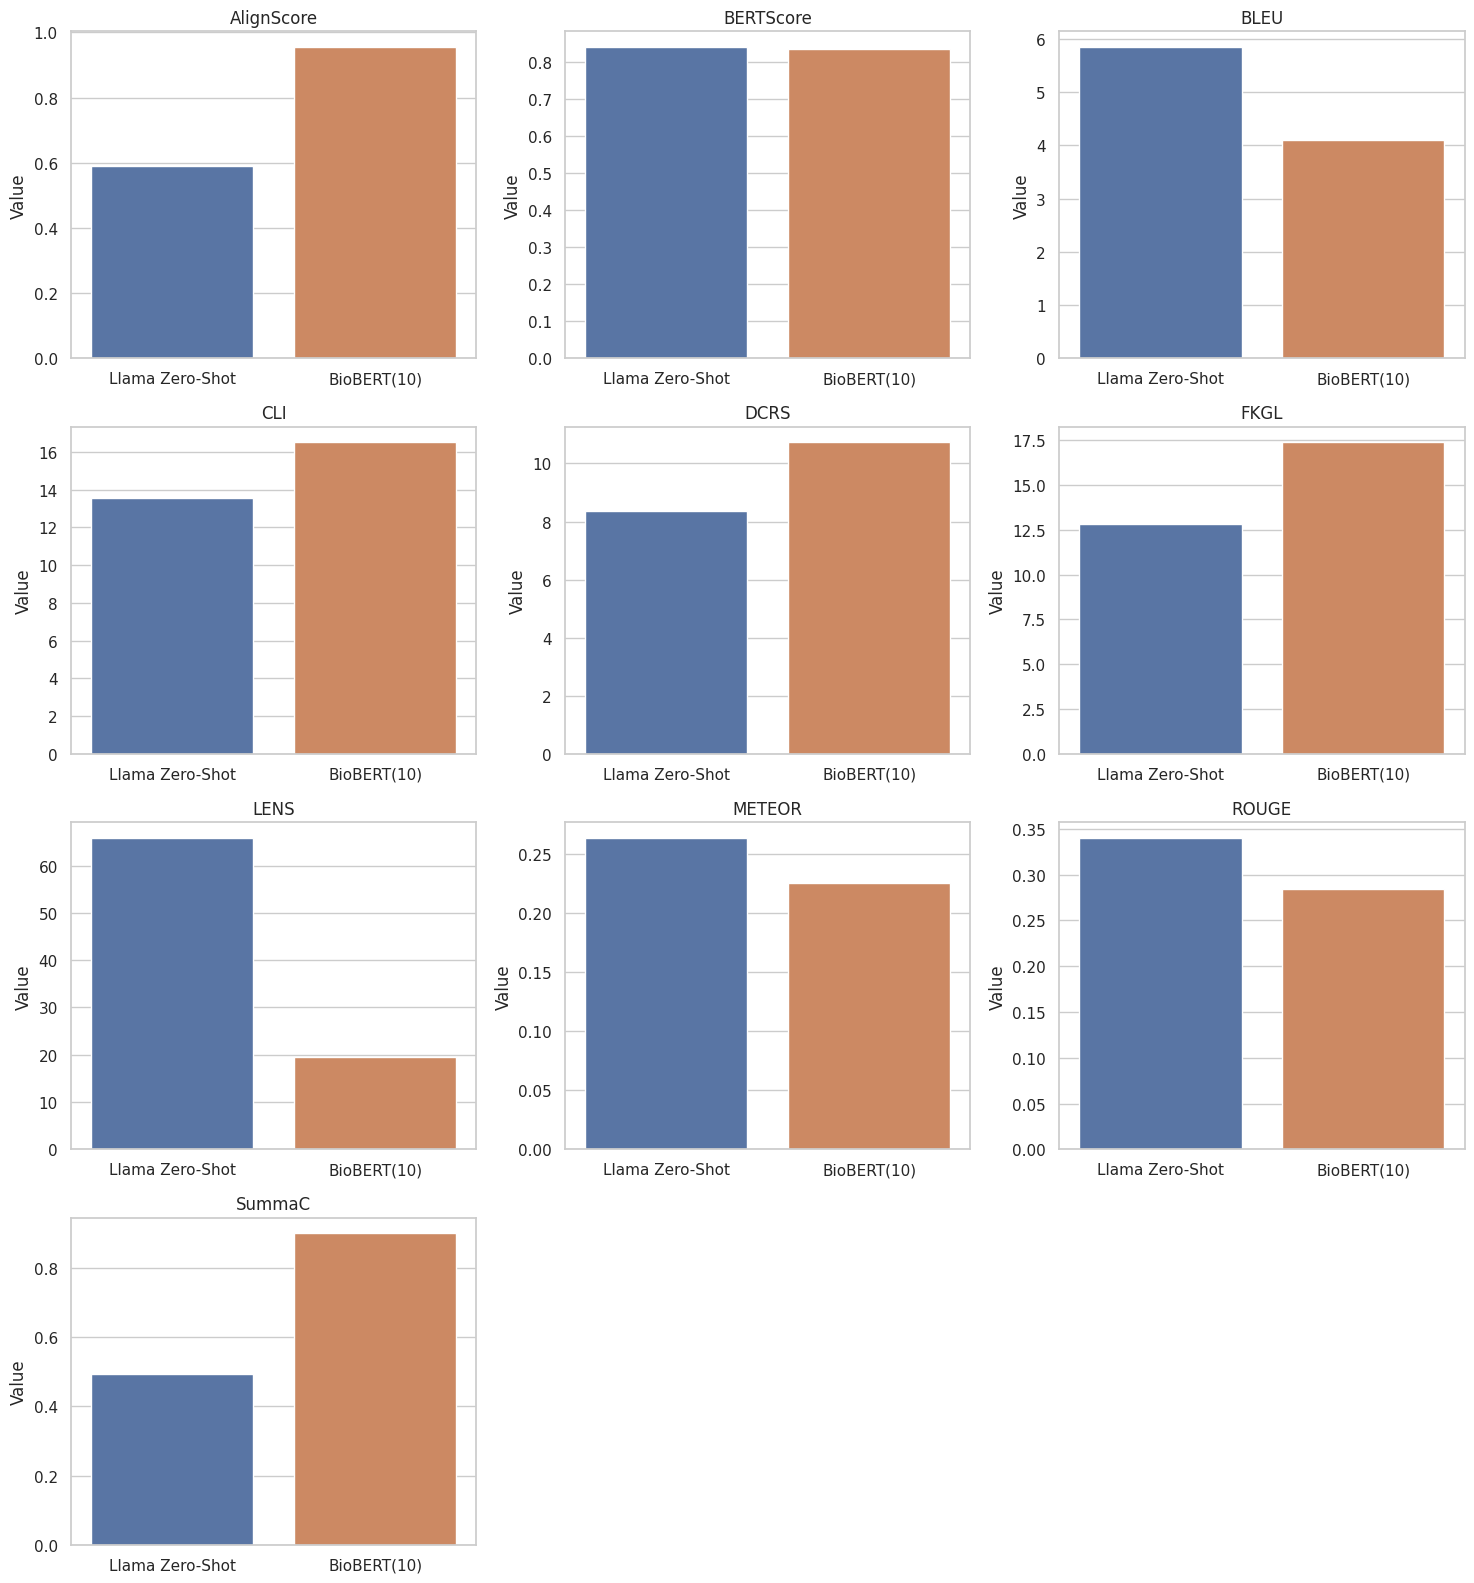

In [56]:
pairwise_comparison(llama_eval, biobert10_eval, ("Llama Zero-Shot", "BioBERT(10)"))

### Llama Zero-Shot vs. BioBERT(20)

Llama Zero-Shot is better on 7/10 metrics.




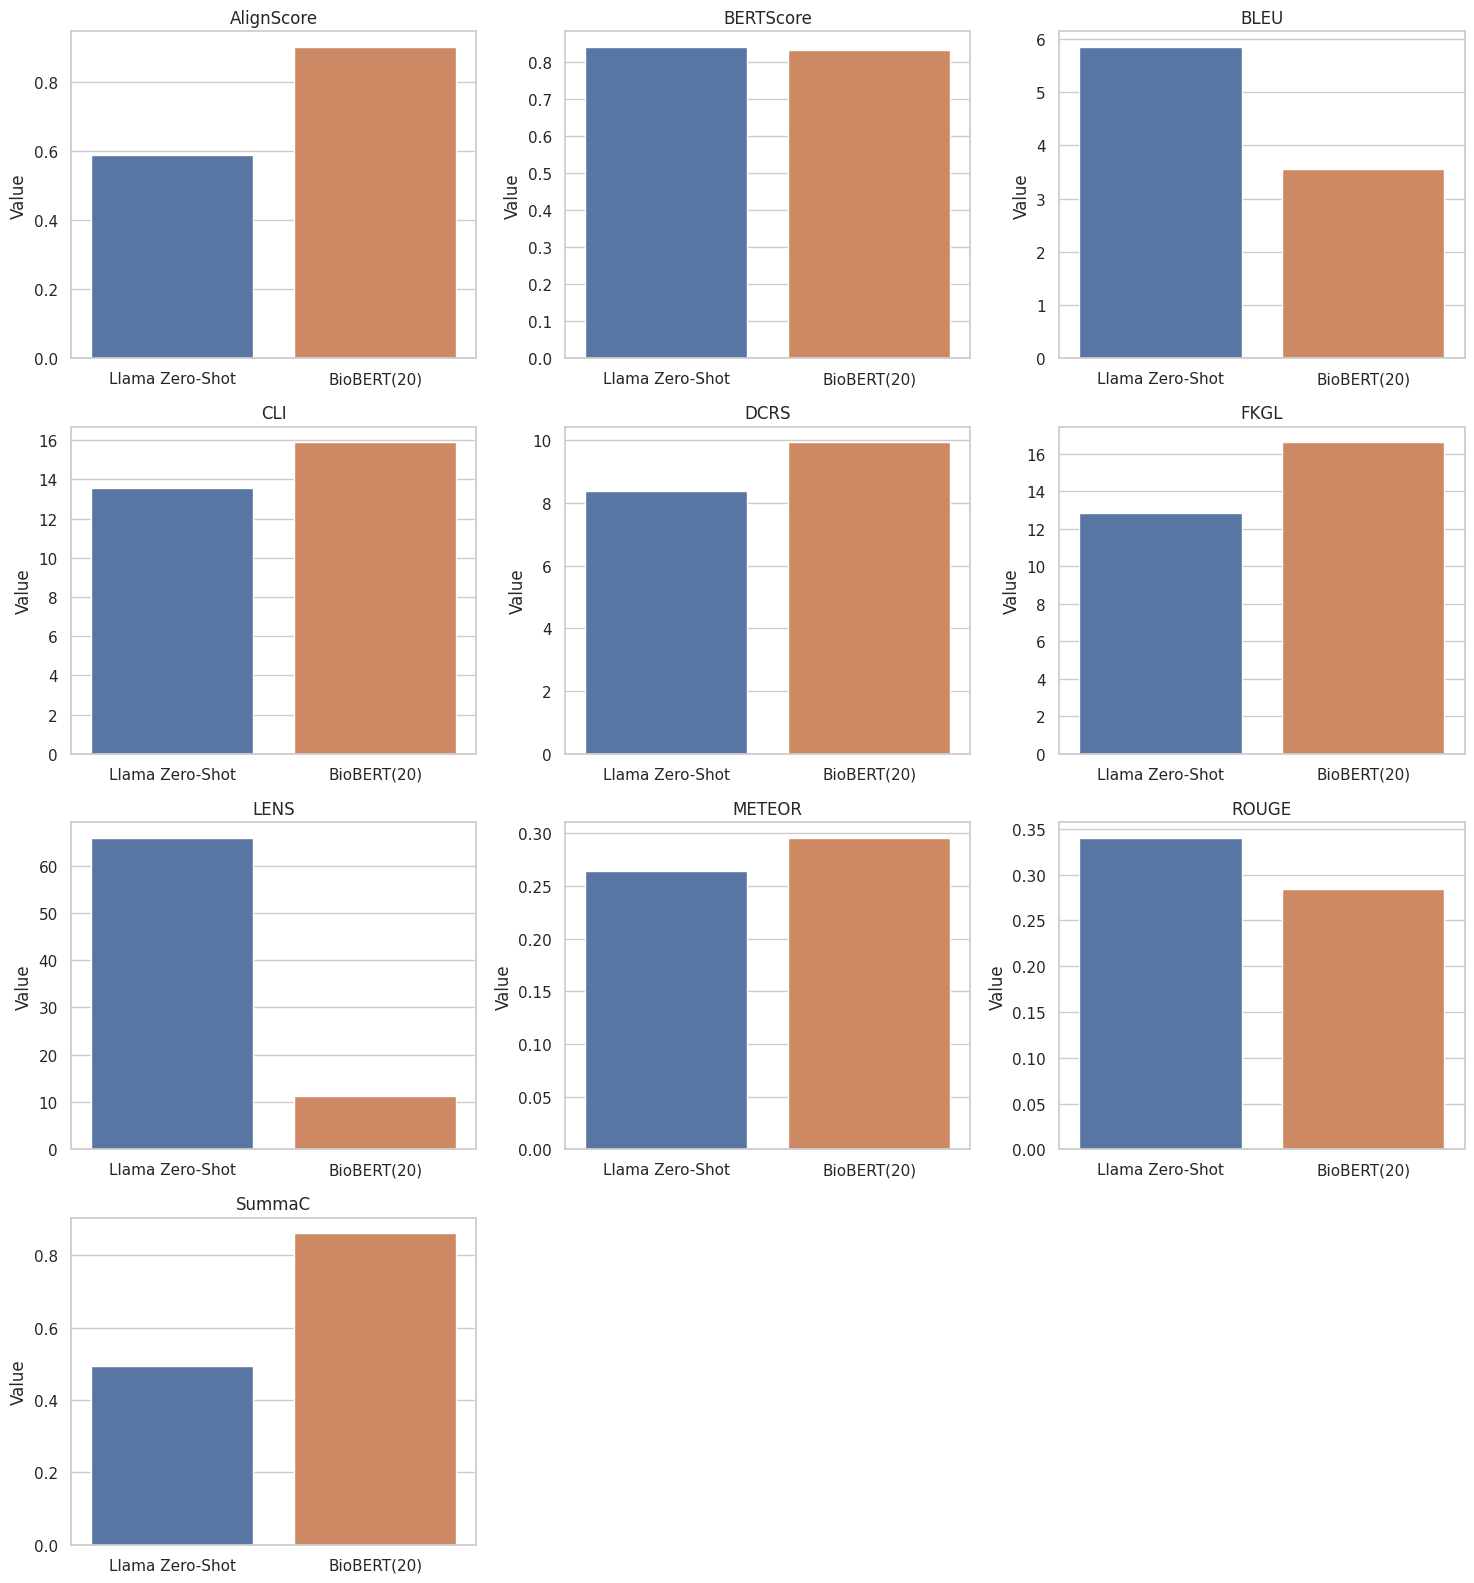

In [57]:
pairwise_comparison(llama_eval, biobert20_eval, ("Llama Zero-Shot", "BioBERT(20)"))

### Llama Zero-Shot vs. Llama+Extractive(30)

Llama+Extractive(30) is better on 6/10 metrics.




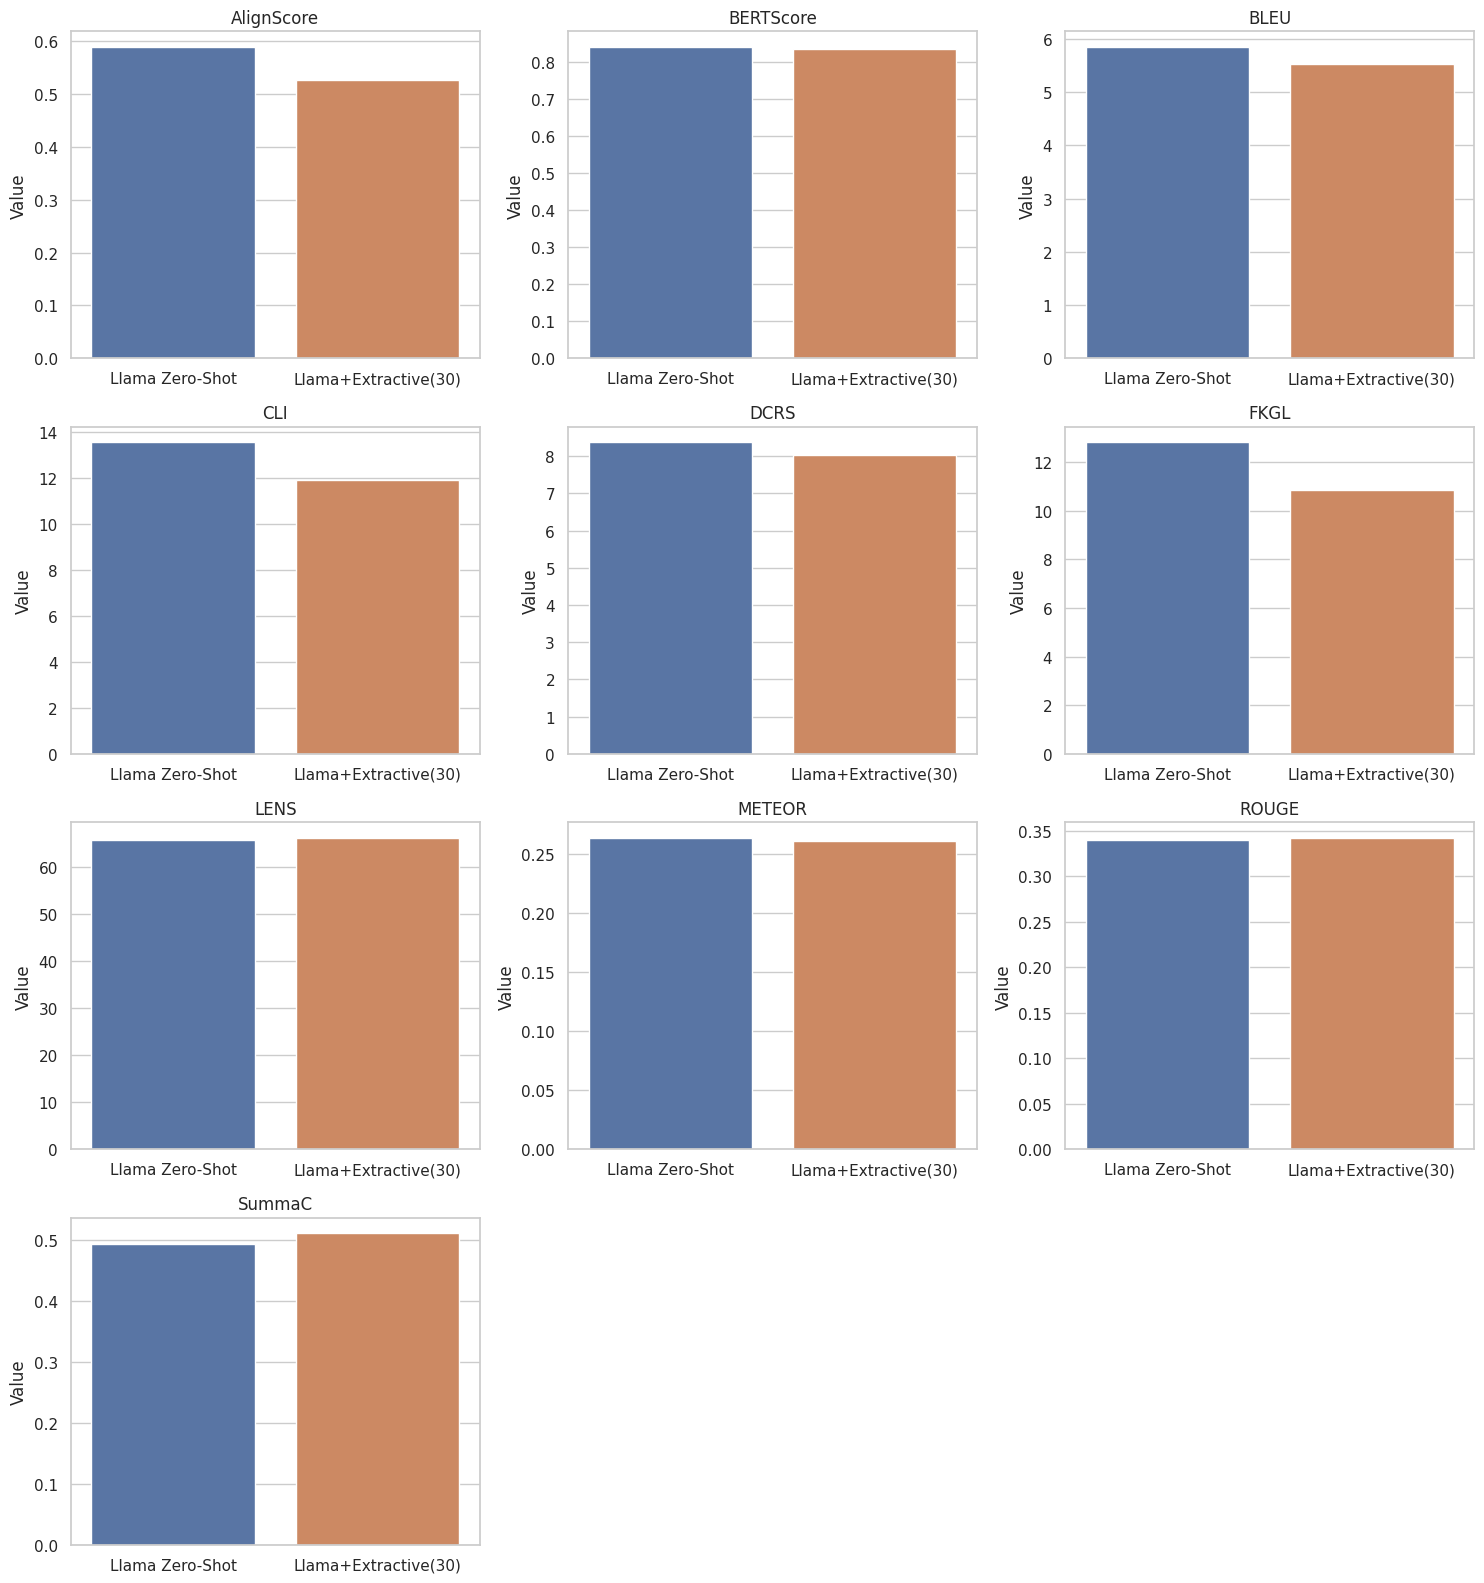

In [58]:
pairwise_comparison(llama_eval, extractive_zeroshot30_eval, ("Llama Zero-Shot", "Llama+Extractive(30)"))

## Finetuned Models

### Llama Zero-Shot vs. Finetuned BioBERT(20) Epoch 1

F_BioBERT(20)_e1 is better on 10/10 metrics.




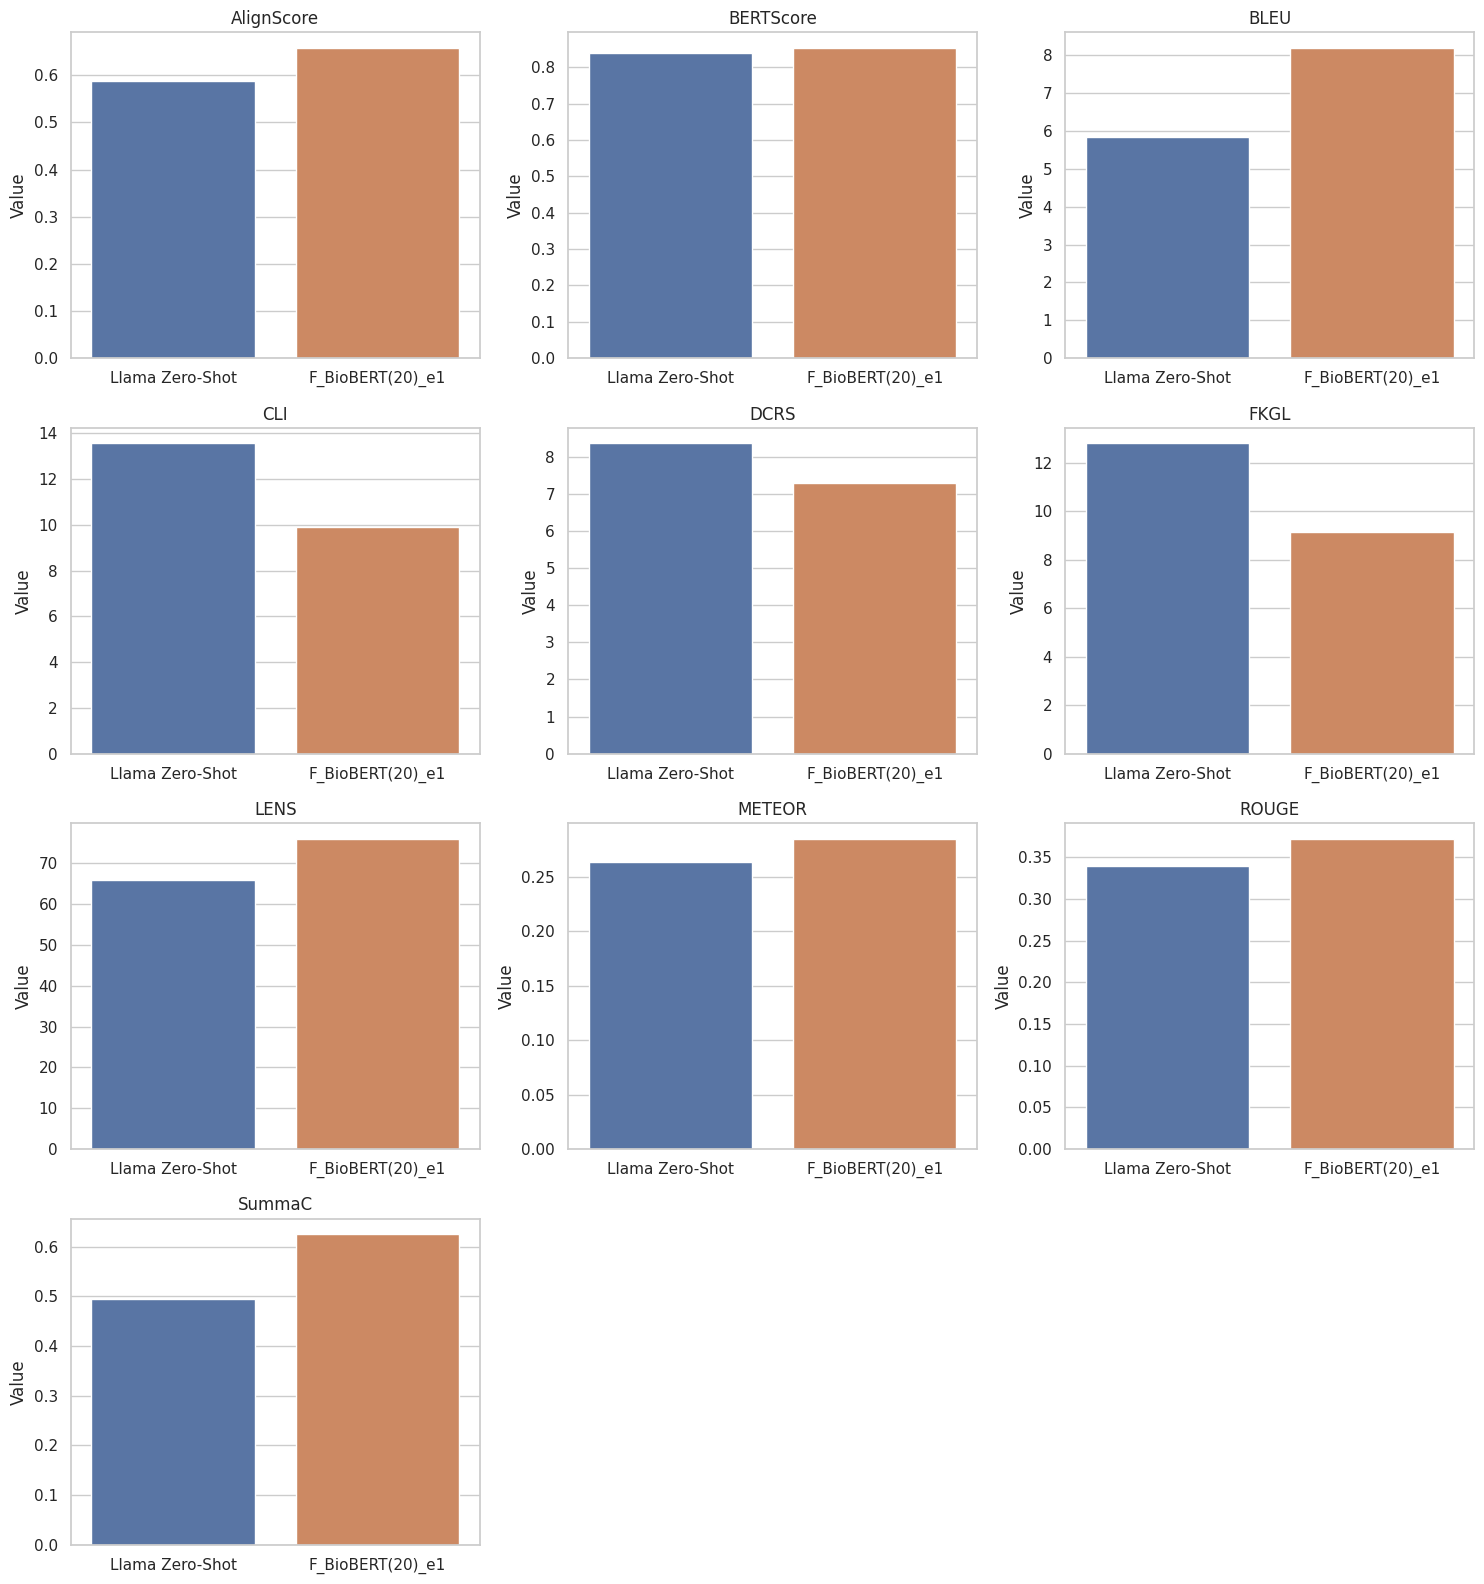

In [59]:
pairwise_comparison(llama_eval, finetuned_biobert20_e1_eval, ("Llama Zero-Shot", "F_BioBERT(20)_e1"))

### Finetuned BioBERT(20) Epoch 1 vs. Finetuned BioBERT(10) Epoch 1

F_BioBERT(20)_e1 is better on 9/10 metrics.




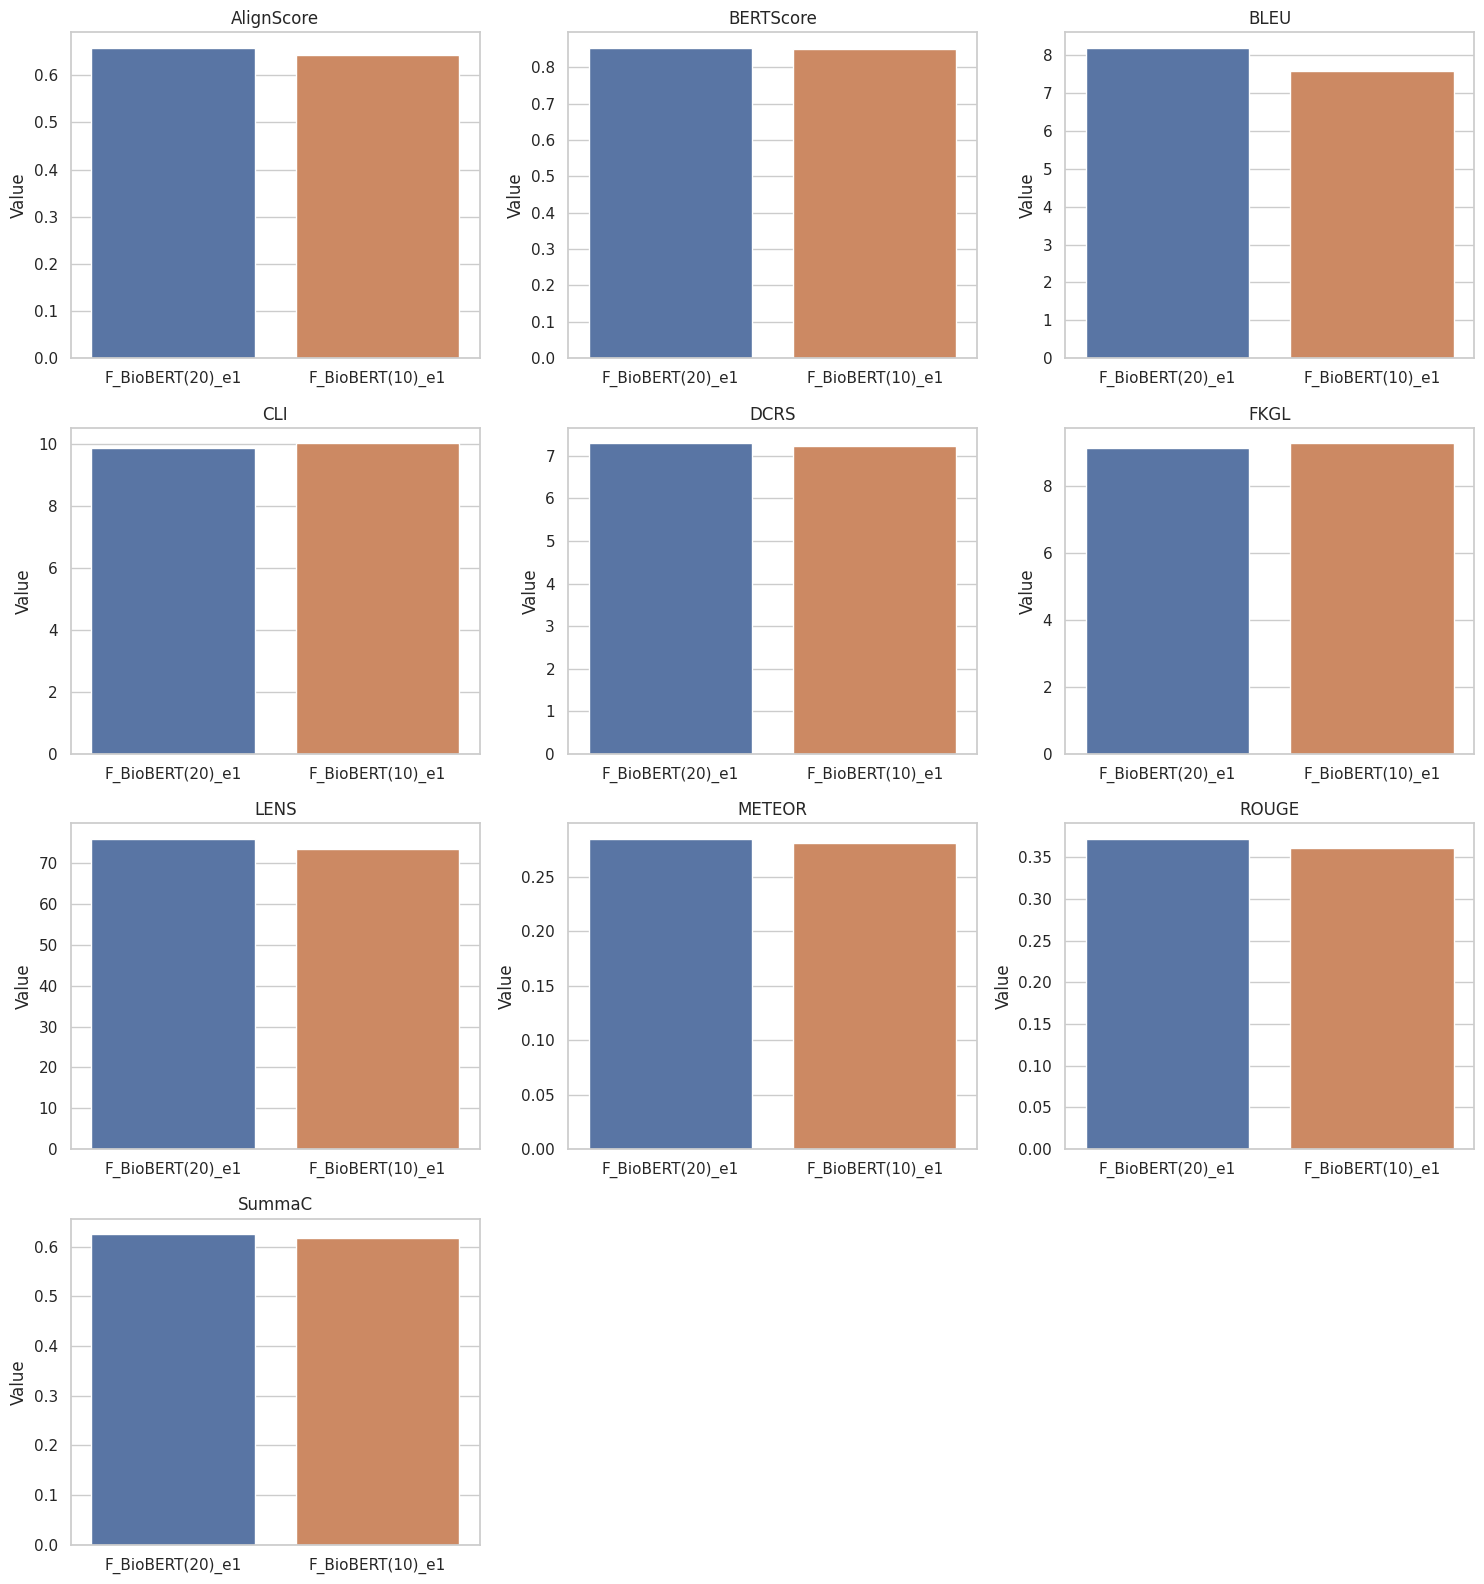

In [60]:
pairwise_comparison(finetuned_biobert20_e1_eval, finetuned_biobert10_e1_eval, ("F_BioBERT(20)_e1", "F_BioBERT(10)_e1"))

### Finetuned BioBERT(20) Epoch 1 vs. Finetuned BioBERT(30) Epoch 1

F_BioBERT(20)_e1 is better on 8/10 metrics.




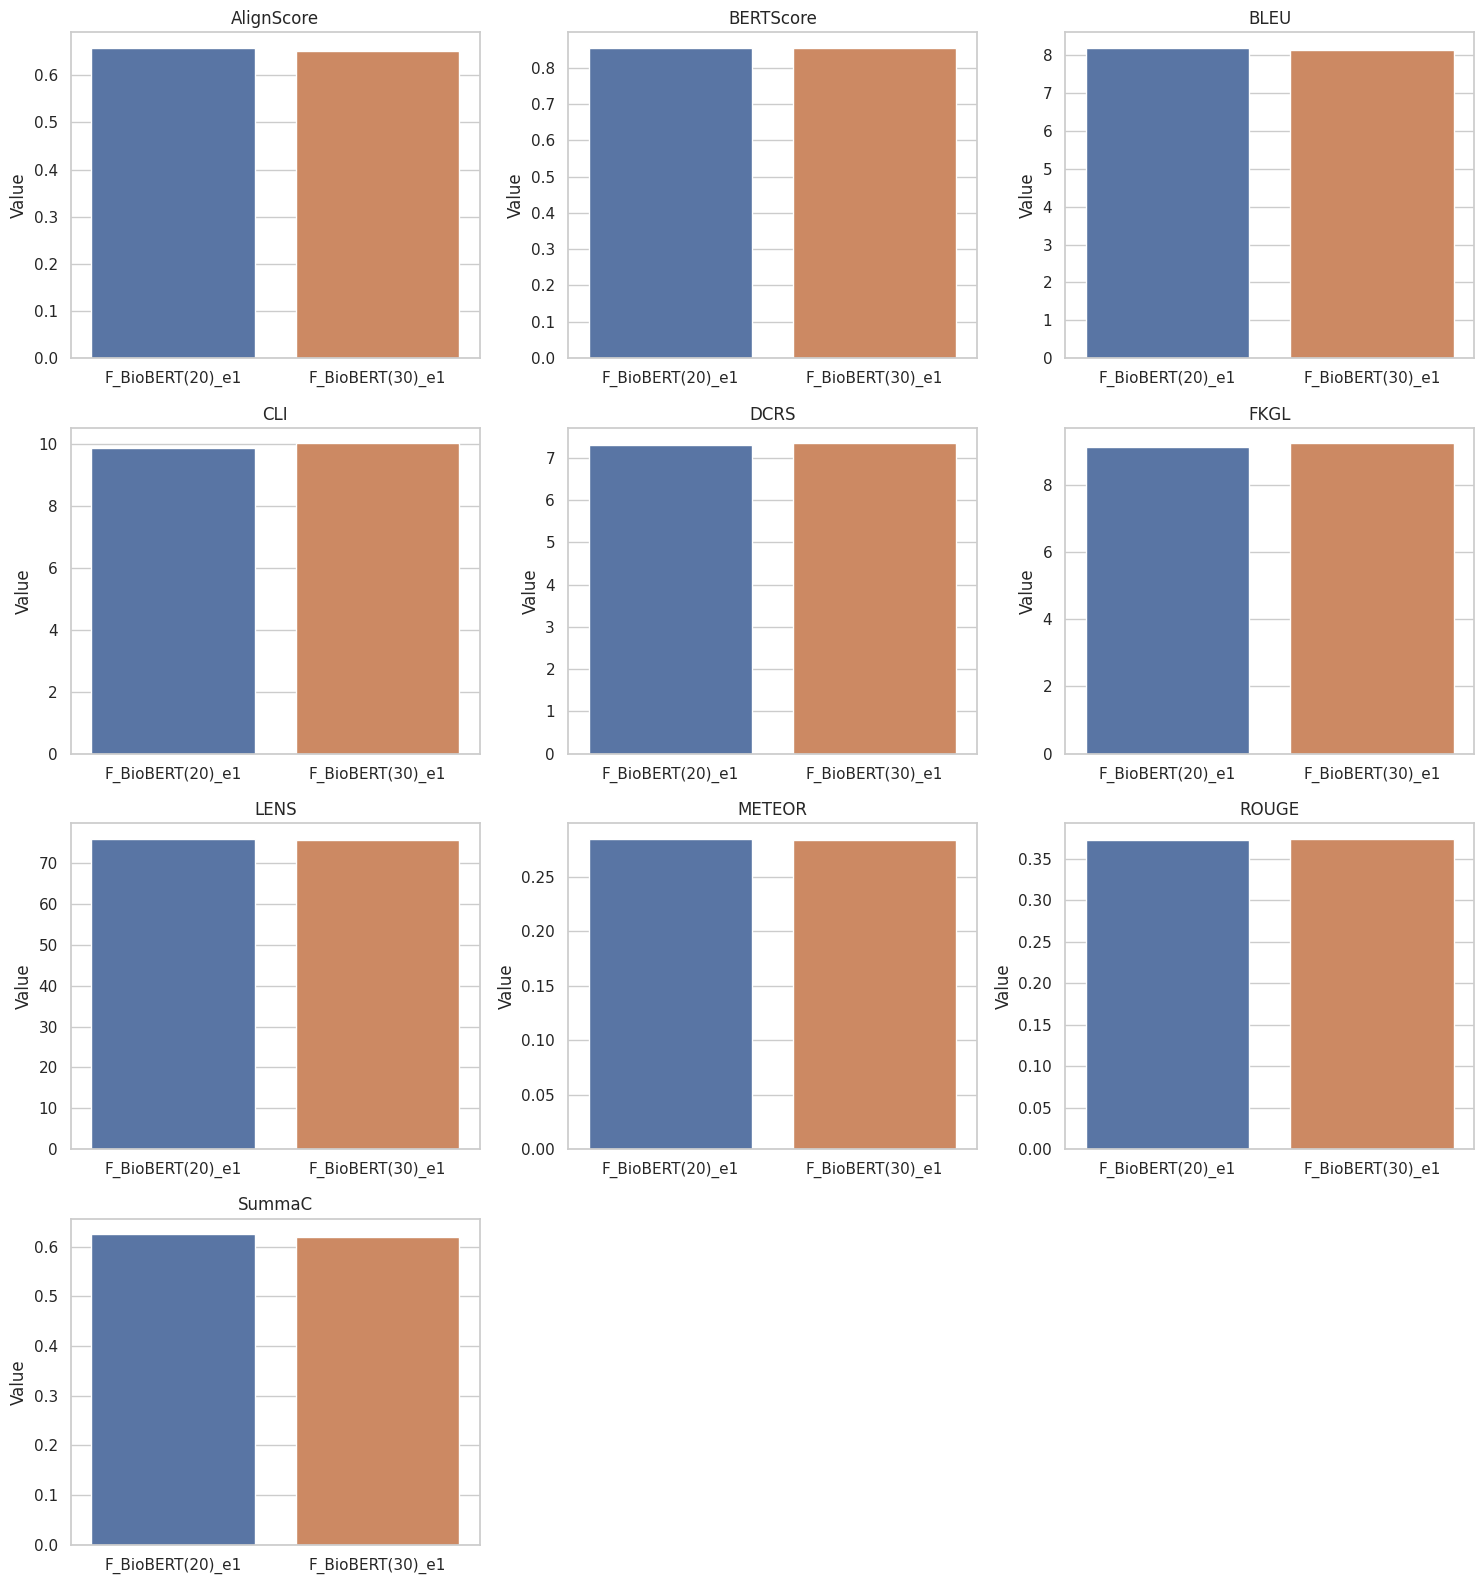

In [61]:
pairwise_comparison(finetuned_biobert20_e1_eval, finetuned_biobert30_e1_eval, ("F_BioBERT(20)_e1", "F_BioBERT(30)_e1"))

### Finetuned BioBERT(20) Epoch 1 vs. Finetuned BioBERT(40) Epoch 1

F_BioBERT(40)_e1 is better on 6/10 metrics.




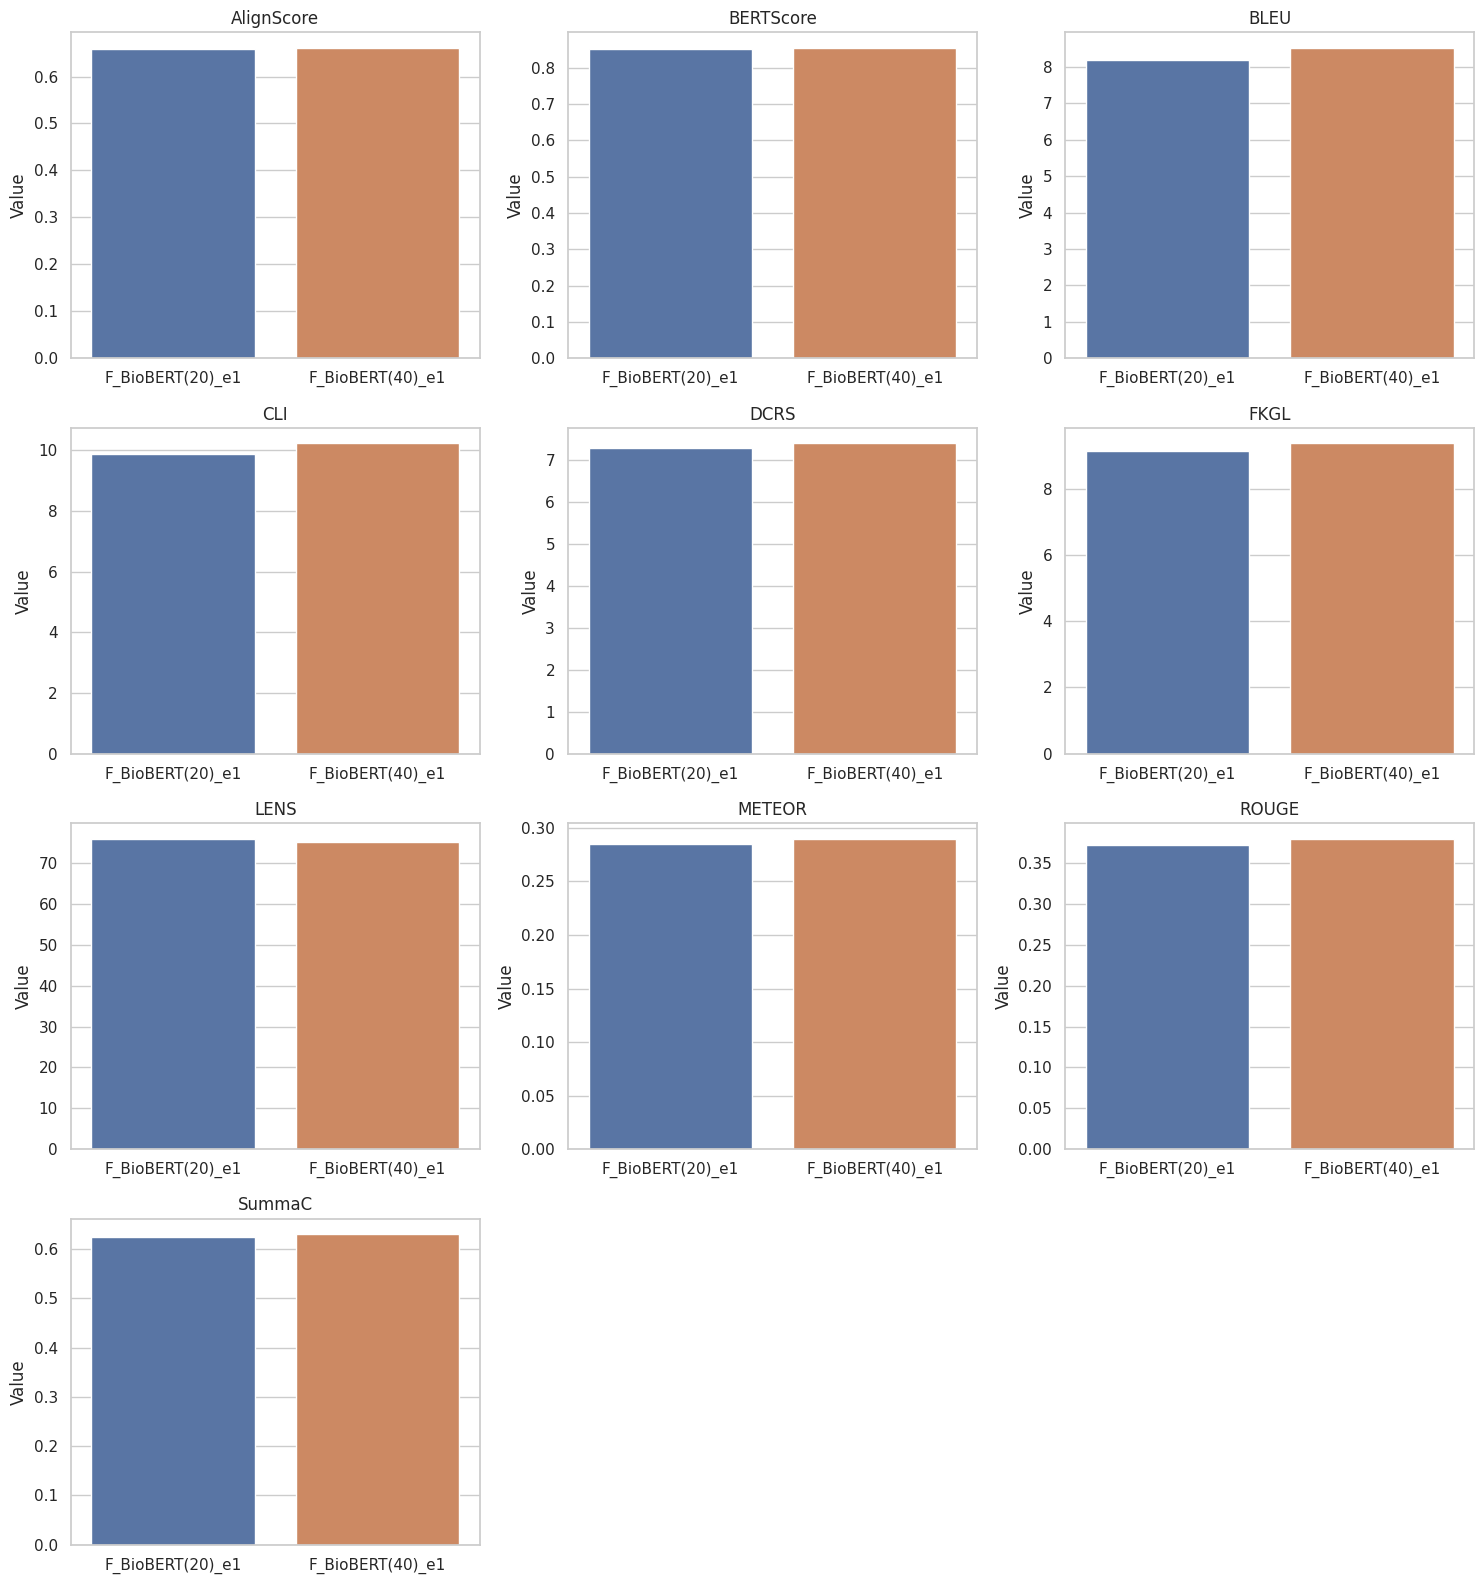

In [62]:
pairwise_comparison(finetuned_biobert20_e1_eval, finetuned_biobert40_e1_eval, ("F_BioBERT(20)_e1", "F_BioBERT(40)_e1"))

### Finetuned BioBERT(20) Epoch 1 vs. Finetuned BioBERT(20) Epoch 2

F_BioBERT(20)_e1 is better on 8/10 metrics.




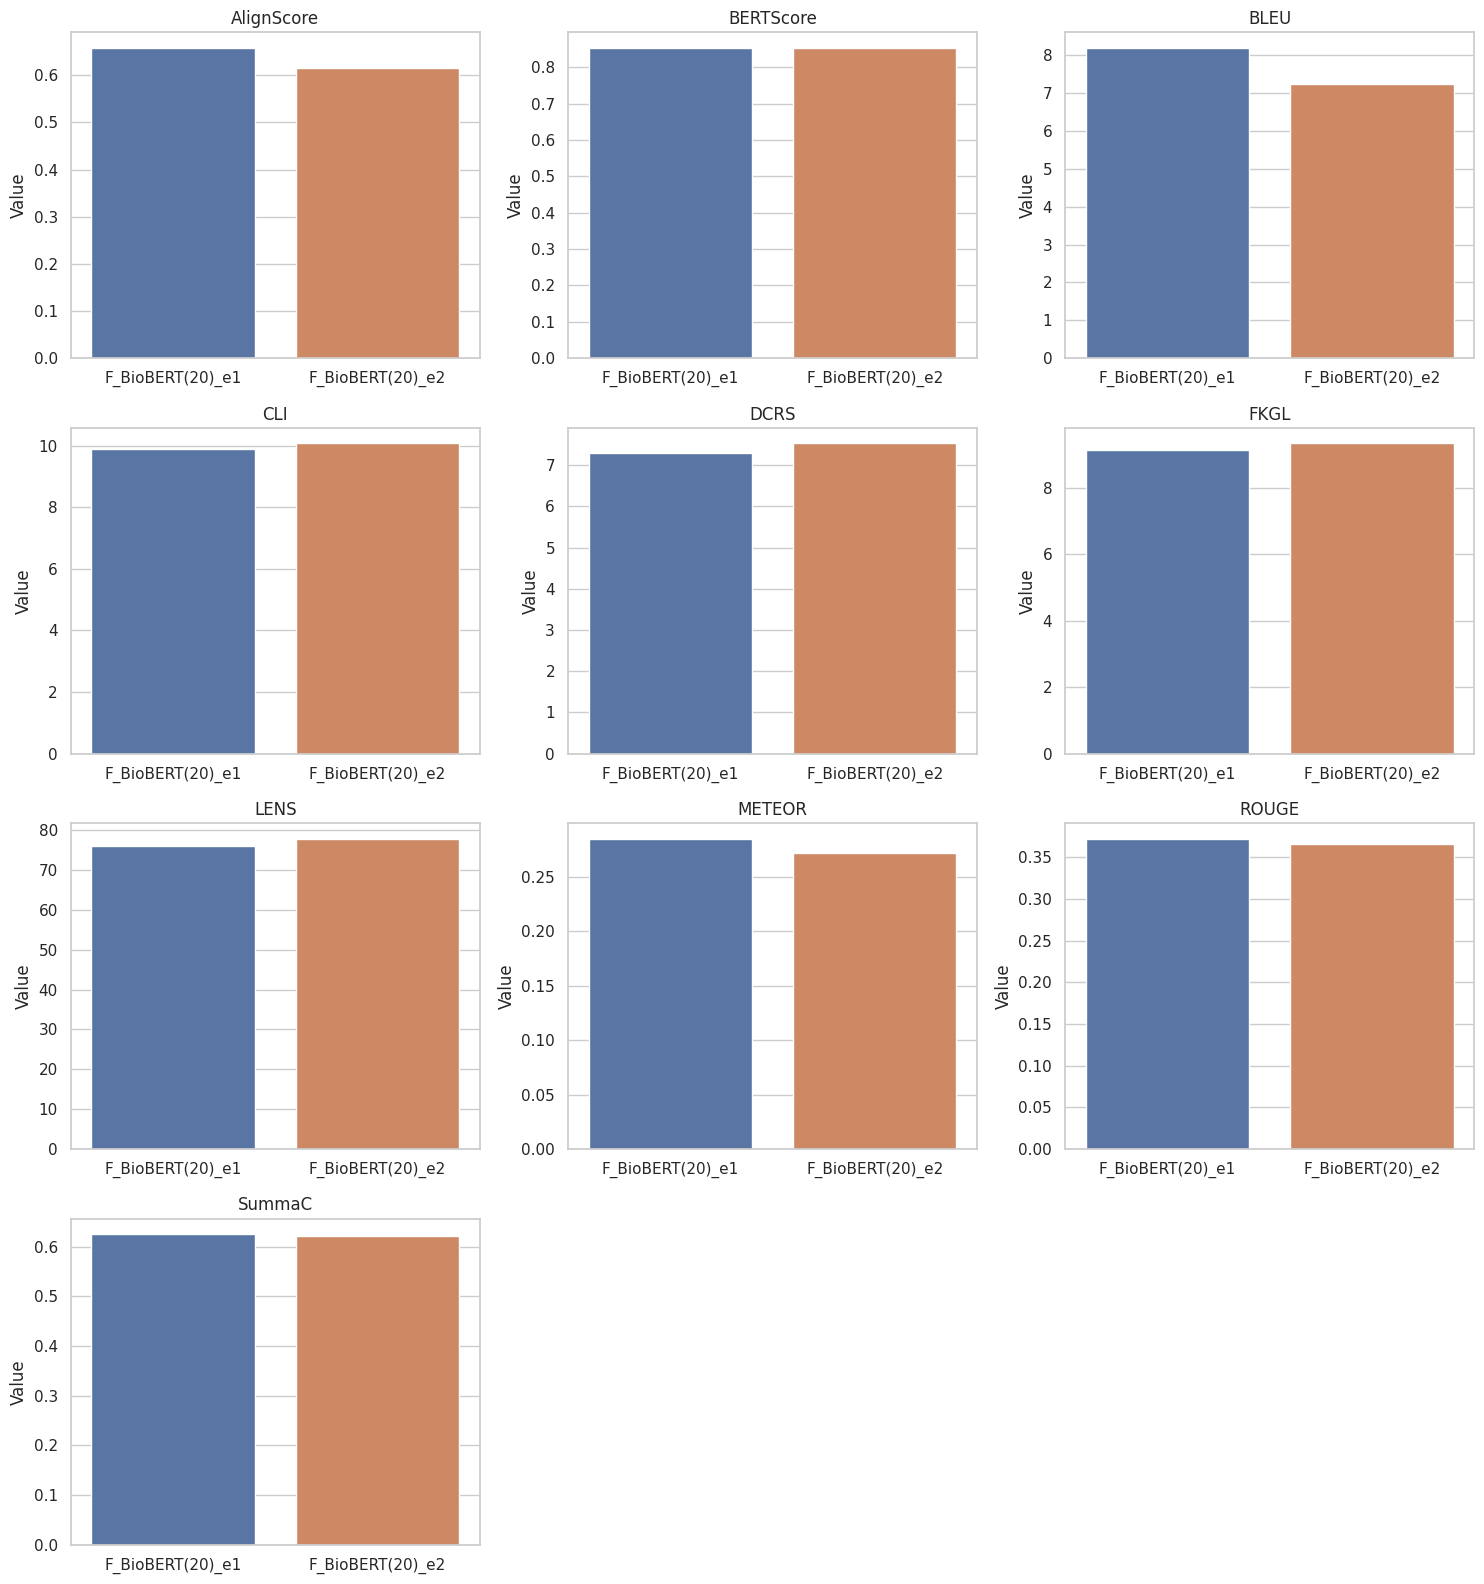

In [63]:
pairwise_comparison(finetuned_biobert20_e1_eval, finetuned_biobert20_e2_eval, ("F_BioBERT(20)_e1", "F_BioBERT(20)_e2"))

### Finetuned BioBERT(40) Epoch 1 vs. Finetuned BioBERT(40) Epoch 2

Tie


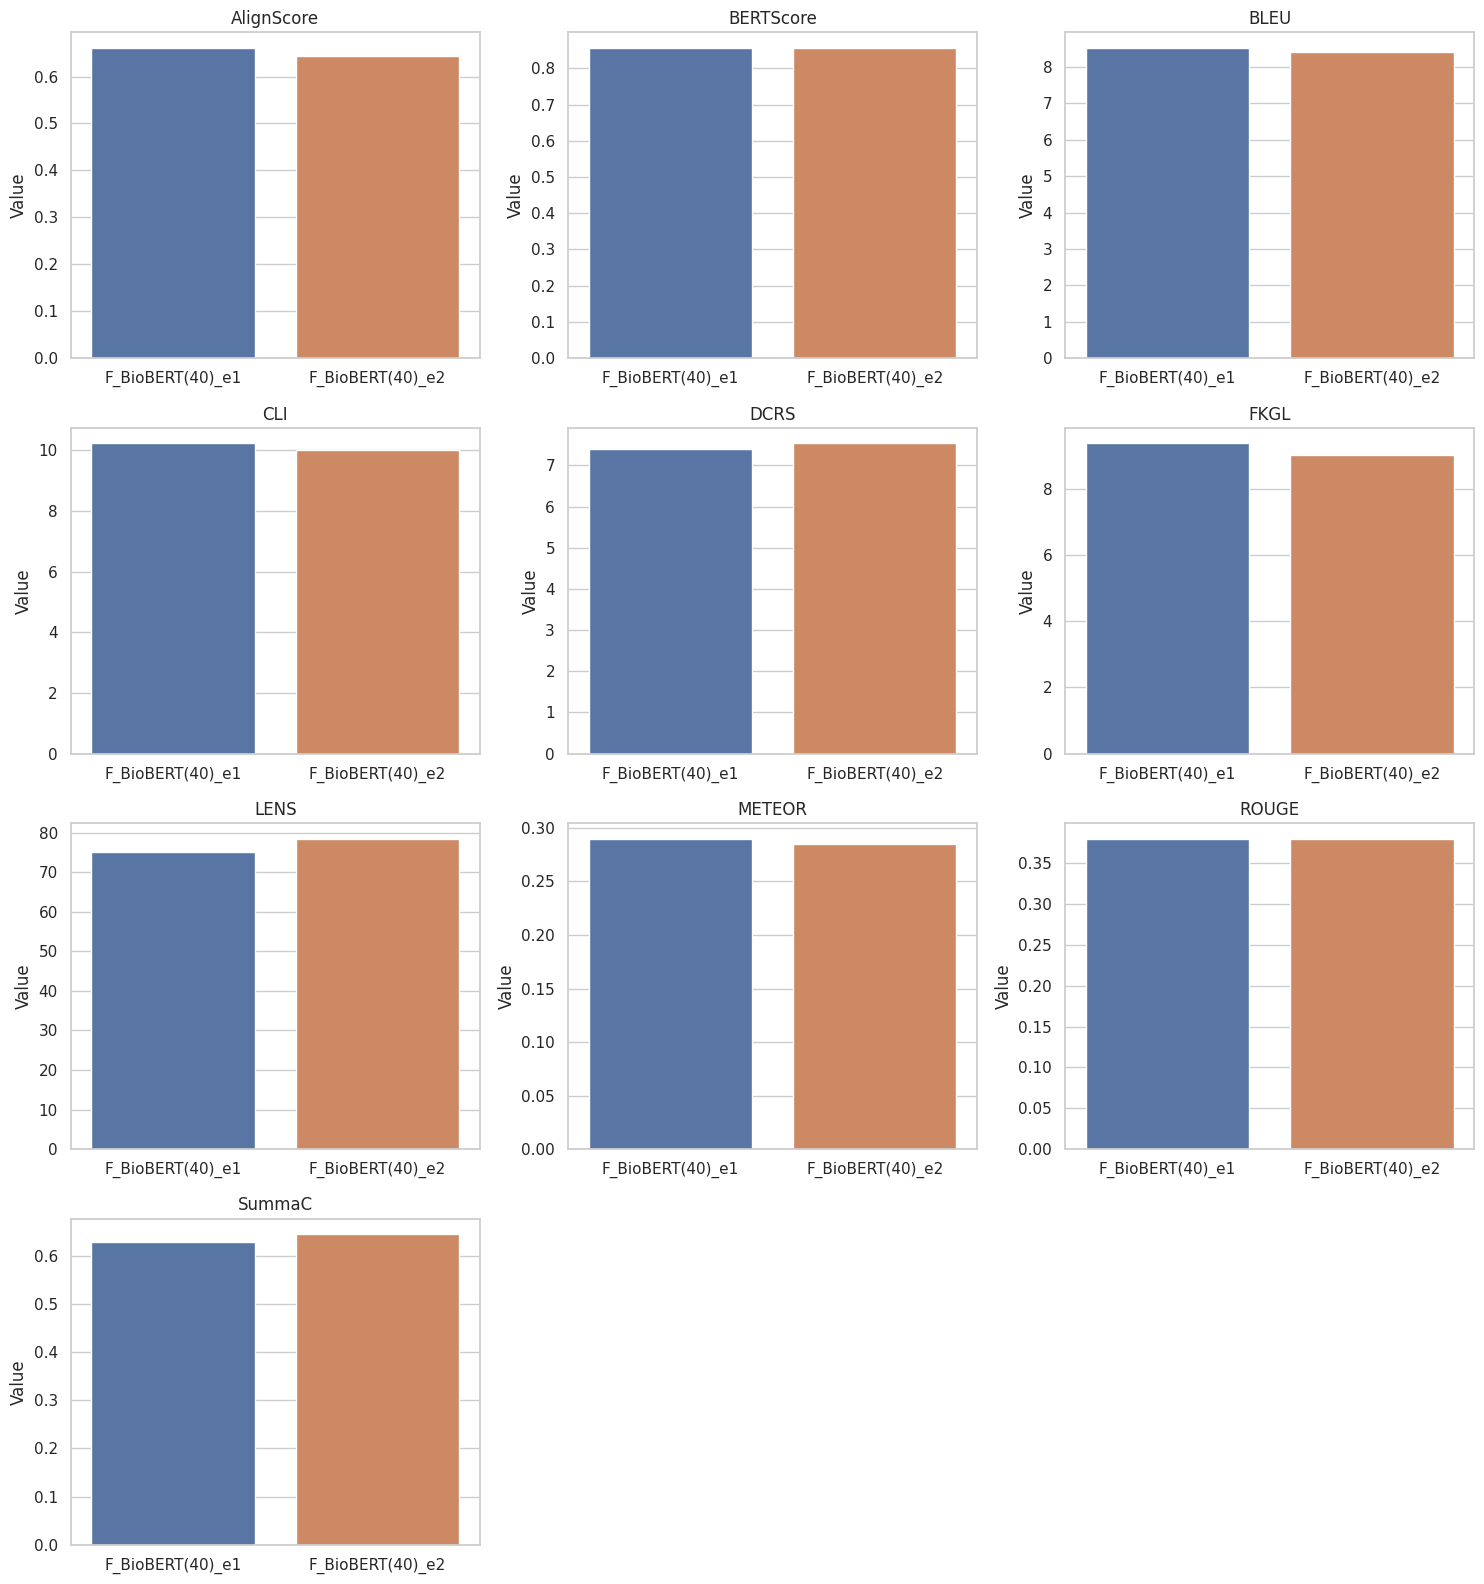

In [64]:
pairwise_comparison(finetuned_biobert40_e1_eval, finetuned_biobert40_e2_eval, ("F_BioBERT(40)_e1", "F_BioBERT(40)_e2"))